In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sentence_transformers import SentenceTransformer

print("Libraries imported successfully!")

c:\Users\SOWNDARIYA N\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


In [6]:
df = pd.read_csv("../dataset/sample_sentences.csv")

sentences = df["Sentence"].tolist()

print("Sample Sentences:")

for sentence in sentences:
    print(sentence)

Sample Sentences:
The bird flies over the trees.
The teacher explains the lesson.
The child enjoys playing with toys.
Deep learning can recognize complex patterns.
Natural language processing helps computers understand human language.."


In [7]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    sentences,
    convert_to_numpy=True
)

print("Embeddings generated successfully!")
print("\nEmbedding Shape:")
print(embeddings.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1674.77it/s]


Embeddings generated successfully!

Embedding Shape:
(5, 384)


In [9]:
np.save(
    "../dataset/embeddings.npy",
    embeddings
)

print("Embeddings saved successfully!")

Embeddings saved successfully!


In [10]:
print("Embedding Matrix:")
print(embeddings)

Embedding Matrix:
[[ 0.0837725   0.05016847  0.07497696 ... -0.05360955  0.0176596
   0.06980153]
 [-0.0311019   0.09462682 -0.04121644 ...  0.12279586 -0.01138057
   0.02875105]
 [ 0.0064136  -0.02868468  0.04659851 ...  0.08089899  0.07949994
   0.13024476]
 [-0.08964191 -0.05569536  0.06290718 ...  0.05566447  0.00501424
  -0.08635558]
 [ 0.0368253   0.01724934  0.05592629 ...  0.11281852  0.04878139
  -0.05525172]]


In [12]:
np.random.seed(42)

embedding_dim = embeddings.shape[1]

W_Q = np.random.randn(
    embedding_dim,
    embedding_dim
)

W_K = np.random.randn(
    embedding_dim,
    embedding_dim
)

W_V = np.random.randn(
    embedding_dim,
    embedding_dim
)

Q = embeddings @ W_Q
K = embeddings @ W_K
V = embeddings @ W_V

print("Query (Q) Matrix:")
print(Q)

print("\nKey (K) Matrix:")
print(K)

print("\nValue (V) Matrix:")
print(V)

Query (Q) Matrix:
[[ 0.34800251 -0.28162128 -0.22149842 ...  0.08023065 -0.55570235
   0.09078597]
 [ 0.17998424 -1.94663568  1.51983975 ... -1.35610421  0.19467204
   1.01776229]
 [ 1.16496429 -1.26274794  0.84010667 ... -1.8766783   0.20583984
   0.09064507]
 [-0.22630062 -0.2982786  -1.41312245 ...  1.49321813  0.83605078
   1.26668859]
 [ 0.37648661 -0.25405354 -1.11861912 ...  1.0263559  -1.80890986
  -0.41398862]]

Key (K) Matrix:
[[-1.22462575 -0.71867627 -1.0285369  ... -1.68184689  0.44063668
   0.57244042]
 [ 1.37114426  0.53984237 -0.10434511 ...  1.17062985  0.4994332
   1.29946811]
 [ 2.65330587  0.2966816   0.36064775 ... -0.57523072  0.08563708
   0.74334285]
 [ 0.49470735 -1.8328036  -0.48878522 ...  1.56096454  2.49988879
   1.70399632]
 [-0.92136679  1.39206185 -0.43523427 ...  1.28277953 -1.1275142
  -0.29041649]]

Value (V) Matrix:
[[ 0.63323101  1.12083713 -0.20094752 ... -1.61028565 -0.81589339
  -1.23575191]
 [-0.12107166 -0.48102337  0.10585244 ... -0.23980293  

In [13]:
attention_scores = Q @ K.T

print("Attention Scores:")
print(attention_scores)

Attention Scores:
[[-18.49656678 -13.85719165  29.54701865   7.88097153 -15.80119978]
 [  7.27008765   0.48229743 -24.02332197  24.34211061 -17.90668471]
 [ 38.35117687   8.22404874   9.4079145   -9.50153496 -15.06345014]
 [-27.68813105  38.47508746   6.19397723   1.46519821  11.64277848]
 [-22.45415286  15.79025993 -17.93636406  30.08623553  17.68639094]]


In [14]:
scaled_scores = (
    attention_scores /
    np.sqrt(embedding_dim)
)

print("Scaled Attention Scores:")
print(scaled_scores)

Scaled Attention Scores:
[[-0.94389897 -0.70714685  1.50781498  0.40217414 -0.8063516 ]
 [ 0.37100011  0.02461214 -1.22593502  1.24220313 -0.91379668]
 [ 1.9571003   0.41968173  0.48009563 -0.48487318 -0.76870347]
 [-1.41295402  1.96342359  0.31608508  0.07477058  0.59414305]
 [-1.14585869  0.80579333 -0.91531125  1.53533178  0.90255486]]


In [16]:
def softmax(x):
    x = x - np.max(
        x,
        axis=-1,
        keepdims=True
    )

    exp_x = np.exp(x)

    return exp_x / np.sum(
        exp_x,
        axis=-1,
        keepdims=True
    )


attention_weights = softmax(scaled_scores)

print("Attention Weights:")
print(attention_weights)

Attention Weights:
[[0.05300789 0.06716773 0.61532754 0.20367262 0.06082422]
 [0.21851976 0.15454549 0.0442538  0.52221504 0.06046591]
 [0.62666916 0.13469328 0.14308145 0.05451333 0.04104278]
 [0.0209343  0.61263322 0.11796971 0.09267636 0.15578641]
 [0.03158794 0.22238885 0.03977835 0.46126184 0.24498303]]


In [17]:
row_sums = np.sum(
    attention_weights,
    axis=1
)

print("Row Sum of Attention Weights:")
print(row_sums)

Row Sum of Attention Weights:
[1. 1. 1. 1. 1.]


In [18]:
attention_output = (
    attention_weights @ V
)

print("Final Attention Output:")
print(attention_output)

Final Attention Output:
[[ 0.19848266  0.20599375  0.66759279 ... -0.23937113  0.75998162
   1.42063831]
 [ 0.33266763  0.87942013 -0.25174643 ... -1.86632718  0.74720501
  -0.36191048]
 [ 0.41441611  0.71116141  0.07166834 ... -1.11999336 -0.13802212
  -0.56190195]
 [-0.05507749 -0.04614097  0.32524761 ... -0.49882129  1.09781618
  -0.41686476]
 [ 0.11406791  0.71692276  0.04833559 ... -1.59810508  0.90247817
  -0.31464239]]


In [20]:
attention_df = pd.DataFrame(
    attention_weights,
    columns=[
        f"Sentence_{i+1}"
        for i in range(len(sentences))
    ]
)

attention_df.insert(
    0,
    "Sentence",
    sentences
)

attention_df.to_csv(
    "../dataset/attention_weights.csv",
    index=False
)

print("Attention weights saved to dataset/attention_weights.csv")

Attention weights saved to dataset/attention_weights.csv


In [23]:
output_df = pd.DataFrame(attention_output)

output_df.insert(
    0,
    "Sentence",
    sentences
)

output_df.to_csv(
    "../dataset/attention_output.csv",
    index=False
)

print("Attention output saved to dataset/attention_output.csv")

Attention output saved to dataset/attention_output.csv


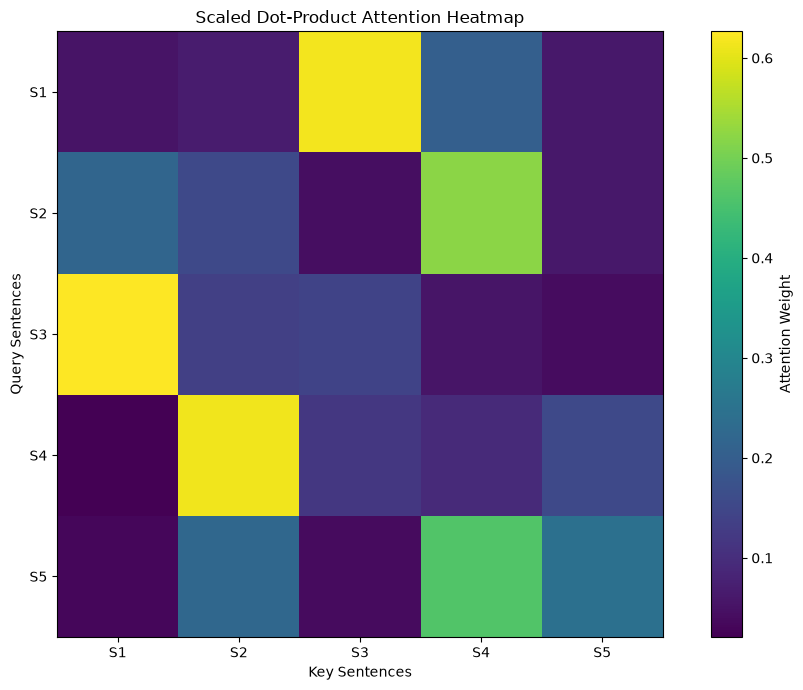

Attention heatmap saved successfully!


In [25]:
plt.figure(figsize=(10, 7))

plt.imshow(
    attention_weights,
    cmap="viridis"
)

plt.xticks(
    range(len(sentences)),
    ["S1", "S2", "S3", "S4", "S5"]
)

plt.yticks(
    range(len(sentences)),
    ["S1", "S2", "S3", "S4", "S5"]
)

plt.xlabel("Key Sentences")
plt.ylabel("Query Sentences")

plt.title(
    "Scaled Dot-Product Attention Heatmap"
)

plt.colorbar(
    label="Attention Weight"
)

plt.tight_layout()

plt.savefig(
    "../dataset/attention_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Attention heatmap saved successfully!")

In [26]:
cmap="viridis"

In [27]:
Q_torch = torch.tensor(
    Q,
    dtype=torch.float32
)

K_torch = torch.tensor(
    K,
    dtype=torch.float32
)

V_torch = torch.tensor(
    V,
    dtype=torch.float32
)

d_k = K_torch.shape[-1]

torch_scores = (
    torch.matmul(Q_torch, K_torch.T)
    / np.sqrt(d_k)
)

torch_weights = torch.softmax(
    torch_scores,
    dim=-1
)

torch_output = torch.matmul(
    torch_weights,
    V_torch
)

print("PyTorch Attention Weights:")
print(torch_weights)

print("\nPyTorch Attention Output:")
print(torch_output)

PyTorch Attention Weights:
tensor([[0.0530, 0.0672, 0.6153, 0.2037, 0.0608],
        [0.2185, 0.1545, 0.0443, 0.5222, 0.0605],
        [0.6267, 0.1347, 0.1431, 0.0545, 0.0410],
        [0.0209, 0.6126, 0.1180, 0.0927, 0.1558],
        [0.0316, 0.2224, 0.0398, 0.4613, 0.2450]])

PyTorch Attention Output:
tensor([[ 0.1985,  0.2060,  0.6676,  ..., -0.2394,  0.7600,  1.4206],
        [ 0.3327,  0.8794, -0.2517,  ..., -1.8663,  0.7472, -0.3619],
        [ 0.4144,  0.7112,  0.0717,  ..., -1.1200, -0.1380, -0.5619],
        [-0.0551, -0.0461,  0.3252,  ..., -0.4988,  1.0978, -0.4169],
        [ 0.1141,  0.7169,  0.0483,  ..., -1.5981,  0.9025, -0.3146]])


In [28]:
difference = np.max(
    np.abs(
        attention_weights -
        torch_weights.detach().numpy()
    )
)

print("Difference between NumPy and PyTorch:")
print(difference)

Difference between NumPy and PyTorch:
1.2501028545663928e-07


In [29]:
print("Embedding Dimension Experiment:")

for dimension in [4, 8, 16, 32]:

    X = embeddings[:, :dimension]

    WQ = np.random.randn(
        dimension,
        dimension
    )

    WK = np.random.randn(
        dimension,
        dimension
    )

    WV = np.random.randn(
        dimension,
        dimension
    )

    q = X @ WQ
    k = X @ WK
    v = X @ WV

    scores = (
        q @ k.T
    ) / np.sqrt(dimension)

    weights = softmax(scores)

    print(
        f"\nEmbedding Dimension: {dimension}"
    )

    print(
        "Attention Matrix Shape:",
        weights.shape
    )

    print(
        "Maximum Attention:",
        np.max(weights)
    )

Embedding Dimension Experiment:

Embedding Dimension: 4
Attention Matrix Shape: (5, 5)
Maximum Attention: 0.2067636094671463

Embedding Dimension: 8
Attention Matrix Shape: (5, 5)
Maximum Attention: 0.2118114424275659

Embedding Dimension: 16
Attention Matrix Shape: (5, 5)
Maximum Attention: 0.216196591933488

Embedding Dimension: 32
Attention Matrix Shape: (5, 5)
Maximum Attention: 0.22057814921146543


In [30]:
print("\n==========================================")
print("Attention Mechanism Project Completed!")
print("==========================================")


Attention Mechanism Project Completed!


# Importance of Attention in Transformer-Based LLMs

## Introduction
Attention is a core mechanism in Transformer-based Large Language Models (LLMs). It helps the model focus on the most relevant words in an input and understand their relationships.

## Importance of Attention

- **Context Understanding:** Attention helps the model understand the meaning of a word based on the surrounding words.
- **Word Relationships:** It identifies relationships between different words in a sentence, even when they are far apart.
- **Long-Range Dependencies:** Attention helps the model connect information across long sequences of text.
- **Efficient Processing:** Transformers use attention to process multiple tokens in parallel, making them more efficient than sequential models.
- **Better Language Tasks:** Attention improves the performance of LLMs in text generation, translation, summarization, question answering, and other NLP tasks.

## Conclusion
Attention is essential for Transformer-based LLMs because it enables them to focus on relevant information and understand context and relationships between words. It plays a major role in making modern language models powerful and effective.